In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append("../utils")
sys.path.append("../training")
import matplotlib.pyplot as plt
import matplotlib
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from geometric_features import get_path_sig
import iisignature
from stage_dataset import StageDataset
from tqdm.auto import tqdm
from umap import UMAP

from scipy.spatial.distance import cdist
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
tqdm.pandas()

# Ideas:
* Do different stages form coherent clusters via path sigs? (this should be fairly fruitful)
* Do different grades form coherent clusters via path sigs? (probably not but could be cool to show different shapes)
* Are there any other patterns, say for certain kinds of clusters, images look one way. (might be a rather involved analysis)

In [2]:
# hyperparameters
model_name = "convlstm2-2026-07-09" #"convlstm_final-2026-07-13"
TIME_OFFSET = 5
PCA_DIM = 8
path_sig_depth = 2

In [3]:
# load latents and metadata
metadata_df = pd.read_csv(os.path.join("latents",f"{model_name}.csv"))
latents = np.load(os.path.join("latents",f"{model_name}.npy"))
latents_df = pd.DataFrame(latents, columns=[f"z_{i}" for i in range(latents.shape[1])], index=metadata_df.index)
pca_cols = [f"pca_{i}" for i in range(PCA_DIM)]
pca_latents = PCA(n_components=PCA_DIM).fit_transform(StandardScaler().fit_transform(latents))
pca_latents_df = pd.DataFrame(pca_latents, columns=pca_cols, index=metadata_df.index)
df = pd.concat([metadata_df, latents_df, pca_latents_df], axis=1)

# pick out some random embryo_ids so that we can look at smaller subsets
embryo_ids = df["embryo_id"].unique()
np.random.shuffle(embryo_ids)
embryo_ids = embryo_ids[:int(len(embryo_ids) * 0.1)]
df = df[df["embryo_id"].isin(embryo_ids)]

In [4]:
ps_cols = [f"path_sig_{i}" for i in range(len(iisignature.basis(iisignature.prepare(PCA_DIM+1, path_sig_depth))))]

def path_sig_agg(group):
    pca_traj = group[pca_cols].to_numpy()
    path_sig = get_path_sig(pca_traj, path_sig_depth, time_offsets=TIME_OFFSET)
    out_df = pd.DataFrame(path_sig[None, :], columns = ps_cols)
    out_df["phase"] = [group.name[1]] # the second key is 'phase'
    return out_df
path_sig_df = df.groupby(["embryo_id", "phase"]).progress_apply(path_sig_agg).reset_index(drop=True)



  0%|          | 0/915 [00:00<?, ?it/s]

/home/jenslundsgaard/ivf/.venv/lib/python3.12/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


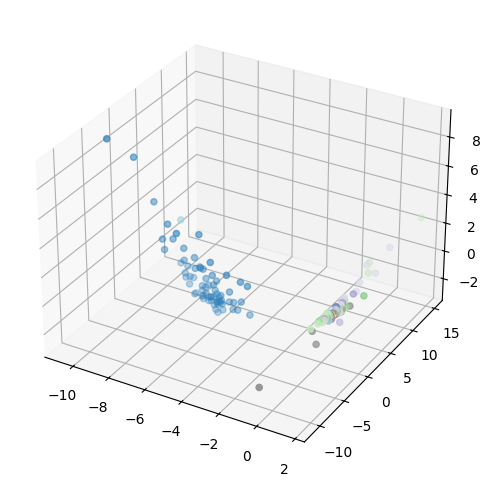

0


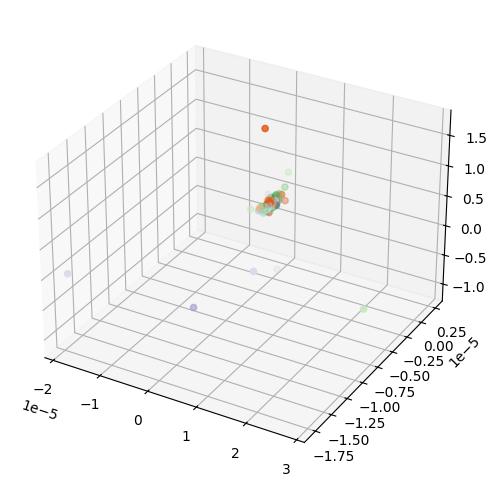

In [5]:
%matplotlib inline
path_sig_df["phase_indices"]  = [StageDataset.PHASES.index(p) for p in path_sig_df['phase'].to_list()]
X = path_sig_df[ps_cols].to_numpy()
y = path_sig_df["phase_indices"].to_numpy()
# X must be positive for whatever reason
X = X + np.abs(X.min())
new_X = PCA(n_components=3).fit_transform(StandardScaler().fit_transform(SelectKBest(chi2, k=5).fit_transform(X, y)))
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection":"3d"})
ax.scatter(new_X[:,0], new_X[:,1], new_X[:,2], c=y, cmap='tab20c', vmin=0, vmax=19)
plt.show()
plt.close(fig)

# now let's look at 
path_sigs = path_sig_df[ps_cols].to_numpy()

# we want to remove outliers
path_sigs_mean = path_sigs.mean(axis=0)
path_sigs_std_dev = path_sigs.std()
path_sigs_dists = cdist(path_sigs, path_sigs_mean[None,:]).squeeze(1)
path_sigs_mask = path_sigs_dists < (path_sigs_std_dev * 1.8)
# remove outliers
normed_path_sig_df = path_sig_df[path_sigs_mask]

normed_path_sigs = StandardScaler().fit_transform(normed_path_sig_df[ps_cols].to_numpy()) / (np.linalg.norm(normed_path_sig_df[ps_cols].to_numpy() ** 2) + 1e-10)
print(np.isnan(normed_path_sigs).sum())
visual_ps = PCA(n_components=3).fit_transform(normed_path_sigs)
visual_ps_colors = normed_path_sig_df["phase_indices"]
fig, ax = plt.subplots(figsize=(8,6), subplot_kw={"projection":"3d"})
ax.scatter(visual_ps[:,0], visual_ps[:,1], visual_ps[:,2], c=visual_ps_colors, cmap='tab20c', vmin=0, vmax=19)
plt.show()
plt.close(fig)